In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import sklearn.metrics
import sklearn.calibration
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import glob, os, unicodedata
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score

from matplotlib import font_manager, rcParams
import glob

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"


In [2]:
def normalize(name):
    """Normalize cancer type names by handling Unicode characters and punctuation."""
    # Normalize unicode (e.g., replace en dash/em dash with hyphen)
    name = unicodedata.normalize('NFKD', name)
    name = name.replace('‑', '-')  # non-breaking hyphen
    name = name.replace('‐', '-')  # hyphen
    name = name.replace('–', '-')  # en dash
    name = name.replace('—', '-')  # em dash
    name = name.replace(',', '')  # remove commas
    # name = name.strip().lower()  # lowercase for uniformity
    return name


heatmap_palette = sns.diverging_palette(h_neg = 270, h_pos = 30, s = 70, l = 60, sep = 7, n = 21, center = 'light')
def heatmap_only(train_labels, stats_full, order, cutoff = 0, normalize = 'pred', other = False, unknown = False, cbar= False, annot_col = sns.color_palette()[-3]):
    #removes anything with probs < cutoff
    stats = stats_full[stats_full.probs>=cutoff] 
    #not sure you'll need this but it just sorts the confusion matrix in the order that I wanted it
    ctype_labels = sorted(train_labels.index.values) 
    sorted_labels = list(order.index)
    if other == True:
        sorted_labels.append("OTHERS")
    if unknown == True:
        sorted_labels.append("UNKNOWN")
    stats = stats.assign(sorted_true = [sorted_labels.index(i) for i in stats.true_label.values])
    stats = stats.assign(sorted_pred = [sorted_labels.index(i) for i in stats.pred_label.values])
    
    #generate CM
    confusion_matrix = sklearn.metrics.confusion_matrix(stats.sorted_true, stats.sorted_pred, normalize = normalize)
    confusion_matrix = confusion_matrix.T
    
    #annotate confusion matrix w/ strings
    annot = 100*confusion_matrix
    annot = pd.DataFrame(annot)
    annot_str = pd.DataFrame(annot.columns).T
    annot_str = annot_str.drop(0, axis = 0)
    for i in range(len(annot)):
        vals = list(annot.iloc[i])
        row = [round(i, 0) for i in vals]
        row = pd.DataFrame(row).T
        annot_str = pd.concat([annot_str, row], ignore_index = True)
    annot_str = np.array(annot_str) if normalize is not None else None
    col_annot_str = []
    for col in annot_str.astype(str):
        row = []
        for val in col:
            row.append(val.split('.')[0] if val.split('.')[0] != '0' else '')
        col_annot_str.append(row)
    col_annot_str = np.array(col_annot_str)
    
    
    #change colors so its red for off-diagonal, otherwise its blue
    mult = np.diag([1]*len(ctype_labels)) if other == False else np.diag([1]*(len(ctype_labels)+1))
    mult[mult == 0] = -1
    confusion_matrix = np.multiply(np.round(confusion_matrix, 2), mult)
    confusion_matrix[confusion_matrix== -0] = 0
    
    #plot
    fig, ax = plt.subplots(dpi=300)
    fig.set_size_inches(10, 10)
    vmax = 1 if normalize is not None else 60
    sns.heatmap(confusion_matrix, vmax=vmax, cmap = heatmap_palette, center = 0,
                cbar = cbar, ax= ax, xticklabels = sorted_labels, yticklabels = sorted_labels, 
                annot = col_annot_str, annot_kws={"fontsize":10}, fmt = '')
    ax.set_xticklabels(sorted_labels, size = 14)
    ax.set_yticklabels(sorted_labels, size = 14)
    #plt.savefig('/home/darmofam/figures/full_hm.svg')
    ax.set_xlabel('True', size = 18)
    ax.set_ylabel('Pred', size = 18)
    plt.show()

#functions for grabbing precision and recall
def precision_stack(stats, cutoff, order):
    # Ensure probs is numeric
    stats = stats.copy()
    stats['probs'] = pd.to_numeric(stats['probs'], errors='coerce').fillna(0)
    
    prec_res = []
    for ct in order:
        ct_sub = stats[stats.prediction1==ct]
        if len(ct_sub) == 0:  # Skip if no predictions for this category
            prec_res.append([0, 0, 0, 0])  # or use NaN values
            continue
        cb = len(ct_sub[(ct_sub.prediction1==ct_sub.ground_truth)&(ct_sub.probs<cutoff)])/len(ct_sub)
        ca = len(ct_sub[(ct_sub.prediction1==ct_sub.ground_truth)&(ct_sub.probs>=cutoff)])/len(ct_sub)
        ib = len(ct_sub[(ct_sub.prediction1!=ct_sub.ground_truth)&(ct_sub.probs<cutoff)])/len(ct_sub)
        ia = len(ct_sub[(ct_sub.prediction1!=ct_sub.ground_truth)&(ct_sub.probs>=cutoff)])/len(ct_sub)
        prec_res.append([ca, cb, ib, ia])
    prec_res = pd.DataFrame(prec_res)
    prec_res.columns = ['Correct, Above', 'Correct, Below', 'Incorrect, Below', 'Incorrect, Above']
    prec_res.index = order
    return prec_res

def recall_stack(stats, cutoff, order):
    # Ensure probs is numeric
    stats = stats.copy()
    stats['probs'] = pd.to_numeric(stats['probs'], errors='coerce').fillna(0)
    
    rec_res = []
    for ct in order:
        ct_sub = stats[stats.ground_truth==ct]  # Changed from prediction1 to ground_truth
        if len(ct_sub) == 0:  # Skip if no ground truth for this category
            rec_res.append([0, 0, 0, 0])
            continue
        cb = len(ct_sub[(ct_sub.prediction1==ct_sub.ground_truth)&(ct_sub.probs<cutoff)])/len(ct_sub)
        ca = len(ct_sub[(ct_sub.prediction1==ct_sub.ground_truth)&(ct_sub.probs>=cutoff)])/len(ct_sub)
        ib = len(ct_sub[(ct_sub.prediction1!=ct_sub.ground_truth)&(ct_sub.probs<cutoff)])/len(ct_sub)
        ia = len(ct_sub[(ct_sub.prediction1!=ct_sub.ground_truth)&(ct_sub.probs>=cutoff)])/len(ct_sub)
        rec_res.append([ca, cb, ib, ia])
    rec_res = pd.DataFrame(rec_res)
    rec_res.columns = ['Correct, Above', 'Correct, Below', 'Incorrect, Below', 'Incorrect, Above']
    rec_res.index = order
    return rec_res
#separate stacks by correctness + confidence
stack_colors  = {'Incorrect, Above': sns.color_palette('dark')[1], 'Incorrect, Below': sns.color_palette('pastel')[1],
                 'Correct, Above': sns.color_palette('deep')[0], 'Correct, Below': sns.color_palette('pastel')[0]}

#separate stacks by correctness only - using purple/orange scheme
stack_colors2  = {'Incorrect, Above': '#7b2d8e', 'Incorrect, Below': '#c99dd4',
                 'Correct, Above': '#d97d2a','Correct, Below': '#f4c4a1'}

def heatmap_maker(train_labels, stats_full, order, cutoff = 0, normalize='pred',
                  other=False, unknown=False, cbar=False,
                  annot_col=sns.color_palette()[-3], filename=None):

    mask_out_val = int(other) + int(unknown)
    stats = stats_full

    # --- ORDER BY DIAGONAL VALUES (i.e., displayed "accuracy" for each cancer) ---
    # Build base list from your canonical order, excluding optional extras
    base_labels = list(order.index)

    # Confusion matrix for sorting uses the SAME normalization you'll plot with
    cm_for_sort = sklearn.metrics.confusion_matrix(
        stats.ground_truth, stats.prediction1,
        labels=base_labels, normalize=normalize
    )
    # Diagonal scores (per-class), highest first
    diag_scores = pd.Series(np.diag(cm_for_sort), index=base_labels).fillna(0.0)
    sorted_core = diag_scores.sort_values(ascending=False).index.tolist()

    # Append optional extras at the end
    sorted_labels = sorted_core.copy()
    if other:
        sorted_labels.append("OTHERS")
    if unknown:
        sorted_labels.append("UNKNOWN")

    # --- Main confusion matrix (same normalize as above) ---
    confusion_matrix = sklearn.metrics.confusion_matrix(
        stats.ground_truth, stats.prediction1,
        normalize=normalize, labels=sorted_labels
    ).T  # rows=pred, cols=true

    # Annotation strings (percent integers if normalized)
    annot = 100 * confusion_matrix
    annot = pd.DataFrame(annot)
    annot_str = pd.DataFrame(annot.columns).T
    annot_str = annot_str.drop(0, axis = 0)
    for i in range(len(annot)):
        vals = list(annot.iloc[i])
        row = [round(i, 0) for i in vals]
        row = pd.DataFrame(row).T
        annot_str = pd.concat([annot_str, row], ignore_index = True)
    annot_str = np.array(annot_str) if normalize is not None else None
    col_annot_str = []
    if annot_str is not None:
        for col in annot_str.astype(str):
            row = []
            for val in col:
                row.append(val.split('.')[0] if val.split('.')[0] != '0' else '')
            col_annot_str.append(row)
        col_annot_str = np.array(col_annot_str)

    # Make off-diagonals negative so reds = wrong, blues = right
    matrix_size = confusion_matrix.shape[0]
    mult = np.diag([1]*matrix_size)
    mult[mult == 0] = -1
    confusion_matrix = np.multiply(np.round(confusion_matrix, 2), mult)
    confusion_matrix[confusion_matrix == -0] = 0

    # ---- Figure layout ----
    fig = plt.figure(figsize=(12, 10), dpi=300)
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 8], width_ratios=[8, 1.5],
                          hspace=0.08, wspace=0.05)

    count_ax   = fig.add_subplot(gs[0, 0])
    null_ax1   = fig.add_subplot(gs[0, 1])
    recall_ax  = fig.add_subplot(gs[1, 0])
    null_ax2   = fig.add_subplot(gs[1, 1])
    heatmap_ax = fig.add_subplot(gs[2, 0])
    precision_ax = fig.add_subplot(gs[2, 1])

    vmax = 1 if normalize is not None else 60

    # If masking final columns (OTHERS/UNKNOWN) on x-axis
    if mask_out_val > 0:
        confusion_matrix = confusion_matrix[:, :-mask_out_val]
        if annot_str is not None:
            col_annot_str = col_annot_str[:, :-mask_out_val]
        x_sorted_labels = np.array(sorted_labels)[:-mask_out_val]
    else:
        x_sorted_labels = sorted_labels

    # --- Keep every panel in the same (sorted) class order ---
    # Top: Count bars
    train_labels_sorted = train_labels.reindex(x_sorted_labels).fillna(0)
    train_labels_sorted.plot(kind='bar', ax=count_ax, legend=False,
                             color='grey', width=0.85, edgecolor=None)
    count_ax.set_ylabel('Count', size=10)
    count_ax.set_xlabel('')
    count_ax.set_xticklabels('')
    sns.despine(ax=count_ax)

    # Middle: Recall bars (stacked) — computed in the same class order
    new_order_index = pd.Index(x_sorted_labels)
    df_recall = recall_stack(stats_full, cutoff, new_order_index)
    df_recall.plot(kind='bar', stacked=True, ax=recall_ax, legend=False,
                   color=stack_colors2, width=0.85, edgecolor=None)
    recall_ax.set_ylabel('Recall', size=10)
    recall_ax.set_xlabel('')
    recall_ax.set_xticklabels('')
    recall_ax.set_ylim([0, 1])
    recall_ax.set_yticks([0, 0.5, 1])
    recall_ax.set_yticklabels(['0', '', '1'])
    sns.despine(ax=recall_ax)

    # Bottom: Heatmap
    sns.heatmap(confusion_matrix, vmax=vmax, cmap=heatmap_palette, center=0,
                cbar=cbar, ax=heatmap_ax, xticklabels=x_sorted_labels,
                yticklabels=sorted_labels, annot=col_annot_str,
                annot_kws={"fontsize":8}, fmt='')
    heatmap_ax.set_xticklabels(x_sorted_labels, size=10, rotation=45, ha='right')
    heatmap_ax.set_yticklabels(sorted_labels, size=10, rotation=0)
    heatmap_ax.set_xlabel('True', size=14)
    heatmap_ax.set_ylabel('Prediction', size=14)

    # Right: Precision bars (aligned to heatmap rows / prediction order)
    df_precision = precision_stack(stats_full, cutoff, pd.Index(sorted_labels))
    df_precision[::-1].plot(kind='barh', stacked=True, ax=precision_ax, legend=False,
                            color=stack_colors2, width=0.85, edgecolor=None)
    precision_ax.set_xlabel('Precision', size=10)
    precision_ax.set_ylabel('')
    precision_ax.set_yticklabels('')
    precision_ax.set_xlim([0, 1])
    precision_ax.set_xticks([0, 0.5, 1])
    precision_ax.set_xticklabels(['0', '', '1'])
    sns.despine(ax=precision_ax)

    # Legend & gradient
    null_ax1.axis('off'); null_ax2.axis('off')
    if cutoff > 0:
        legend_elements = [
            plt.Rectangle((0,0),1,1, facecolor=stack_colors2['Correct, Above'],   label=f'Correct, high conf. (>{cutoff})'),
            plt.Rectangle((0,0),1,1, facecolor=stack_colors2['Correct, Below'],   label=f'Correct, low conf. (≤{cutoff})'),
            plt.Rectangle((0,0),1,1, facecolor=stack_colors2['Incorrect, Below'], label=f'Incorrect, low conf. (≤{cutoff})'),
            plt.Rectangle((0,0),1,1, facecolor=stack_colors2['Incorrect, Above'], label=f'Incorrect,  high conf. (>{cutoff})'),
        ]
    else:
        legend_elements = [
            plt.Rectangle((0,0),1,1, facecolor=stack_colors2['Correct, Above'],   label='Correct'),
            plt.Rectangle((0,0),1,1, facecolor=stack_colors2['Incorrect, Above'], label='Incorrect'),
        ]
    null_ax1.legend(handles=legend_elements, loc='upper center', fontsize=8,
                    frameon=False, bbox_to_anchor=(0.6, -0.3))

    # --- Thin "Incorrect ↔ Correct" gradient bar (match old style) ---
    heatmap_cmap = ListedColormap(heatmap_palette)
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    
    # place a very thin strip near the bottom of the null axis
    bar_y0 = 0.02      # bottom of bar (axis coords)
    bar_h  = 0.04      # thickness of bar (was ~0.15)
    null_ax1.set_xlim(0, 1)
    null_ax1.set_ylim(0, 0.25)   # compact vertical space so the strip stays thin
    null_ax1.imshow(gradient, aspect='auto', cmap=heatmap_cmap,
                    extent=[0, 1, bar_y0, bar_y0 + bar_h])
    
    # labels positioned just above and below the strip
    label_y = bar_y0 + bar_h + 0.015
    tick_y  = bar_y0 - 0.015
    null_ax1.text(0,   label_y, 'Incorrect', ha='left',  va='bottom', fontsize=8, weight='bold')
    null_ax1.text(1,   label_y, 'Correct',   ha='right', va='bottom', fontsize=8, weight='bold')
    null_ax1.text(0,   tick_y,  '100',       ha='left',  va='top',    fontsize=7)
    null_ax1.text(0.5, tick_y,  '0',         ha='center',va='top',    fontsize=7)
    null_ax1.text(1,   tick_y,  '100',       ha='right', va='top',    fontsize=7)
    null_ax1.set_xticks([]); null_ax1.set_yticks([])


    # Align precision bars with heatmap rows
    precision_ax.set_position([precision_ax.get_position().x0,
                               heatmap_ax.get_position().y0,
                               precision_ax.get_position().width,
                               heatmap_ax.get_position().height])

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=500, bbox_inches='tight')
    plt.show()

## Load data

In [3]:
"""Load and prepare the genomic data for analysis."""
# Define paths
gdd_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/GDD-ENS/filtered_batch_msk"
o3_mini_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/gpt-5/filtered_batch_msk" #gpt-4o, gpt-5, claude-sonnet-37
medgemma_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/medgemma/filtered_batch_msk"

# Load validation set
val_set = pd.read_csv("/data1/morrisq/yuj13/llm_genomics/genie_output/o3-mini/output_nosite_extended_o3-mini.csv")
val_set["SAMPLE_ID"] = "GENIE-MSK-" + val_set["SAMPLE_ID"].astype(str)

# Load clinical data and mapping
data_clinical_sample = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt',sep='\t',comment='#')
mapping_df = pd.read_table("/data1/morrisq/yuj13/llm_genomics/GDD_ENS/data/tumor_type_final.txt")
mapping_df_unique = mapping_df[['CANCER_TYPE', 'Cancer_Type']].drop_duplicates()
mapping = dict(zip(mapping_df_unique['Cancer_Type'], mapping_df_unique['CANCER_TYPE']))

# Load MSK data
if len(glob.glob(os.path.join(gdd_path, "*.csv"))) > 0:
    val_cancertypes_gdd_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(gdd_path, "*.csv"))), ignore_index=True)
    val_cancertypes_gdd_msk = val_cancertypes_gdd_msk[val_cancertypes_gdd_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

if len(glob.glob(os.path.join(o3_mini_path, "*.csv"))) > 0:
    val_cancertypes_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(o3_mini_path, "*.csv"))), ignore_index=True)
    val_cancertypes_msk = val_cancertypes_msk[val_cancertypes_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

if len(glob.glob(os.path.join(medgemma_path, "*.csv"))) > 0:
    print(len(glob.glob(os.path.join(medgemma_path, "*.csv"))))
    val_cancertypes_gemma_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(medgemma_path, "*.csv"))), ignore_index=True)
    val_cancertypes_gemma_msk = val_cancertypes_gemma_msk[val_cancertypes_gemma_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

# Load non-MSK data
gdd_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/GDD-ENS/filtered_batch_non_msk"
o3_mini_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/gpt-5/filtered_batch_non_msk"
medgemma_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/medgemma/filtered_batch_non_msk"

val_cancertypes_gdd = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(gdd_path_non_msk, "*.csv"))), ignore_index=True)
val_cancertypes = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(o3_mini_path_non_msk, "*.csv"))), ignore_index=True)
val_cancertypes_gemma = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(medgemma_path_non_msk, "*.csv"))), ignore_index=True)

# Combine MSK and non-MSK data
val_cancertypes_gdd = pd.concat([val_cancertypes_gdd, val_cancertypes_gdd_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")
val_cancertypes = pd.concat([val_cancertypes, val_cancertypes_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")
# val_cancertypes_gemma = pd.concat([val_cancertypes_gemma, val_cancertypes_gemma_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")

    
# ------Process GDD data with cancer type mapping-------
print("------------------GDD-ENS-------------------")
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Cancer_Type': 'ground_truth'})
ground_truth_cancers = val_cancertypes_gdd.ground_truth.unique()
gdd_pred_cancers = val_cancertypes_gdd.Pred1.unique()

# Merge with clinical data
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    data_clinical_sample[['SAMPLE_ID', 'CANCER_TYPE_DETAILED', 'SEQ_ASSAY_ID']],
    on='SAMPLE_ID',
    how='left'
)

# Map predictions using mapping_df for Pred1
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    mapping_df,
    left_on=['CANCER_TYPE_DETAILED', 'Pred1'],
    right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
    how='left'
)
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'CANCER_TYPE': 'prediction1'})
val_cancertypes_gdd['prediction1'] = (
    val_cancertypes_gdd['prediction1']
    .fillna(val_cancertypes_gdd['Pred1'].map(mapping))
    .fillna('Unknown')
)

# Map predictions using mapping_df for Pred2
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    mapping_df,
    left_on=['CANCER_TYPE_DETAILED', 'Pred2'],
    right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
    how='left'
)
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'CANCER_TYPE': 'prediction2'})
val_cancertypes_gdd['prediction2'] = (
    val_cancertypes_gdd['prediction2']
    .fillna(val_cancertypes_gdd['Pred2'].map(mapping))
    .fillna('Unknown')
)
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Conf1': 'probs'})
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Conf2': 'probs2'})

# Mapping to numbers
# Get unique values from ground_truth column and sort them alphabetically
# Get all unique values from ground_truth, prediction1, and prediction2
all_unique_values = set(val_cancertypes_gdd['ground_truth'].unique()) | \
                   set(val_cancertypes_gdd['prediction1'].unique()) | \
                   set(val_cancertypes_gdd['prediction2'].unique())

# Sort to ensure consistent ordering
all_unique_values = sorted(all_unique_values)

# Create comprehensive mapping
ground_truth_mapping = {value: idx for idx, value in enumerate(all_unique_values)}

# Apply the mapping
val_cancertypes_gdd['true'] = val_cancertypes_gdd['ground_truth'].map(ground_truth_mapping)
val_cancertypes_gdd['pred'] = val_cancertypes_gdd['prediction1'].map(ground_truth_mapping)
val_cancertypes_gdd['pred2'] = val_cancertypes_gdd['prediction2'].map(ground_truth_mapping)

unknown_rows_gdd = val_cancertypes_gdd[val_cancertypes_gdd['prediction1'] == "UNKNOWN"]
print(f"Number of Unknown rows in GDD predictions: {len(unknown_rows_gdd)}")

print("-------------------------------------------------------------")
# ------Process o3-mini data with cancer type mapping-------
print("------------------O3-mini-------------------")
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].fillna('UNKNOWN')
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].fillna('UNKNOWN')
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].apply(normalize)
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].apply(normalize)

# Fix specific cancer type naming inconsistencies
# Define the values to replace
values_to_replace = {'Indeterminate', 'Not Applicable', 'Unclassifiable', 'Undetermined'}

# Assuming val_cancertypes is your DataFrame
# Replace the specified values with 'UNKNOWN' in prediction1 and prediction2 columns
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].replace(values_to_replace, 'UNKNOWN')
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].replace(values_to_replace, 'UNKNOWN')

val_cancertypes.loc[val_cancertypes['prediction1'] == 'Skin Cancer Non-Melanoma', 'prediction1'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Non-Small-Cell Lung Cancer', 'prediction1'] = 'Non-Small Cell Lung Cancer'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'CNS Cancer (likely meningioma)', 'prediction1'] = 'CNS Cancer'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromat Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromatic Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromenchymal Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
other_cancers = set(val_cancertypes.prediction1.unique()) - set(val_cancertypes.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in O3-mini prediction1: {other_cancers}")
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].replace(other_cancers, 'OTHERS')

val_cancertypes.loc[val_cancertypes['prediction2'] == 'Skin Cancer Non-Melanoma', 'prediction2'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Non-Small Cell Lung Cancer', 'prediction2'] = 'Non-Small Cell Lung Cancer'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Malignant Mesothelioma', 'prediction2'] = 'Mesothelioma'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Papillary Thyroid Cancer', 'prediction2'] = 'Thyroid Cancer'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Gastrointestinal Stromen Tumor', 'prediction2'] = 'Gastrointestinal Stromal Tumor'
other_cancers = set(val_cancertypes.prediction2.unique()) - set(val_cancertypes.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in O3-mini prediction2: {other_cancers}")
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].replace(other_cancers, 'OTHERS')

# Mapping to numbers
# Get unique values from ground_truth column and sort them alphabetically
unique_ground_truth = sorted(val_cancertypes['ground_truth'].unique())
ground_truth_mapping = {value: idx for idx, value in enumerate(unique_ground_truth)}
val_cancertypes['true'] = val_cancertypes['ground_truth'].map(ground_truth_mapping)
val_cancertypes['pred'] = val_cancertypes['prediction1'].map(ground_truth_mapping)
val_cancertypes['pred2'] = val_cancertypes['prediction2'].map(ground_truth_mapping)

# Mapping to numbers
# Get unique values from ground_truth column and sort them alphabetically
# Get all unique values from ground_truth, prediction1, and prediction2
all_unique_values = set(val_cancertypes['ground_truth'].unique()) | \
                   set(val_cancertypes['prediction1'].unique()) | \
                   set(val_cancertypes['prediction2'].unique())

# Sort to ensure consistent ordering
all_unique_values = sorted(all_unique_values)

# Create comprehensive mapping
ground_truth_mapping = {value: idx for idx, value in enumerate(all_unique_values)}

# Apply the mapping
val_cancertypes['true'] = val_cancertypes['ground_truth'].map(ground_truth_mapping)
val_cancertypes['pred'] = val_cancertypes['prediction1'].map(ground_truth_mapping)
val_cancertypes['pred2'] = val_cancertypes['prediction2'].map(ground_truth_mapping)

val_cancertypes = val_cancertypes.rename(columns={'prob1': 'probs'})
val_cancertypes = val_cancertypes.rename(columns={'prob2': 'probs2'})

unknown_rows_o3_mini = val_cancertypes[val_cancertypes['prediction1'] == "UNKNOWN"]
others_rows_o3_mini = val_cancertypes[val_cancertypes['prediction1'] == "OTHERS"]
print(f"Number of UNKNOWN rows in O3-mini predictions: {len(unknown_rows_o3_mini)}")
print(f"Number of OTHERS rows in O3-mini predictions: {len(others_rows_o3_mini)}")
print("-------------------------------------------------------------")

# ------Process medgemma data with cancer type mapping-------
print("------------------MedGemma-------------------")
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].fillna('UNKNOWN')
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].fillna('UNKNOWN')
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].apply(normalize)
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].apply(normalize)

# Fix specific cancer type naming inconsistencies
# Define the values to replace
values_to_replace = {'UNKNOWN', 'Unknown'}

# Assuming val_cancertypes is your DataFrame
# Replace the specified values with 'UNKNOWN' in prediction1 and prediction2 columns
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].replace(values_to_replace, 'UNKNOWN')
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].replace(values_to_replace, 'UNKNOWN')

val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Skin Cancer Non-Melanoma', 'prediction1'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Clear Cell Renal Cell Carcinoma', 'prediction1'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Papillary Cell Renal Cell Carcinoma', 'prediction1'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Urothelial Cancer (Bladder Cancer)', 'prediction1'] = 'Bladder Cancer'
other_cancers = set(val_cancertypes_gemma.prediction1.unique()) - set(val_cancertypes_gemma.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in MedGemma prediction1: {other_cancers}")
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].replace(other_cancers, 'OTHERS')

val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Skin Cancer Non-Melanoma', 'prediction2'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Clear Cell Renal Cell Carcinoma', 'prediction2'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Papillary Cell Renal Cell Carcinoma', 'prediction2'] = 'Renal Cell Carcinoma'
other_cancers = set(val_cancertypes_gemma.prediction2.unique()) - set(val_cancertypes_gemma.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in MedGemma prediction2: {other_cancers}")
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].replace(other_cancers, 'OTHERS')

# Get all unique values from ground_truth, prediction1, and prediction2
all_unique_values = set(val_cancertypes_gemma['ground_truth'].unique()) | \
                   set(val_cancertypes_gemma['prediction1'].unique()) | \
                   set(val_cancertypes_gemma['prediction2'].unique())

# Sort to ensure consistent ordering
all_unique_values = sorted(all_unique_values)

# Create comprehensive mapping
ground_truth_mapping = {value: idx for idx, value in enumerate(all_unique_values)}

# Apply the mapping
val_cancertypes_gemma['true'] = val_cancertypes_gemma['ground_truth'].map(ground_truth_mapping)
val_cancertypes_gemma['pred'] = val_cancertypes_gemma['prediction1'].map(ground_truth_mapping)
val_cancertypes_gemma['pred2'] = val_cancertypes_gemma['prediction2'].map(ground_truth_mapping)

val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prob1': 'probs'})
val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prob2': 'probs2'})
unknown_rows_gemma = val_cancertypes_gemma[val_cancertypes_gemma['prediction1'] == "UNKNOWN"]
others_rows_gemma = val_cancertypes_gemma[val_cancertypes_gemma['prediction1'] == "OTHERS"]
print(f"Number of UNKNOWN rows in MedGemma predictions: {len(unknown_rows_gemma)}")
print(f"Number of OTHERS rows in MedGemma predictions: {len(others_rows_gemma)}")
print("-------------------------------------------------------------")


1
------------------GDD-ENS-------------------
Number of Unknown rows in GDD predictions: 0
-------------------------------------------------------------
------------------O3-mini-------------------
Other cancer type in O3-mini prediction1: {'Gastrointestinal Stromor Tumor', 'Non-Small C Lung Cancer', 'Esophagogastrric Cancer', 'Non-Small Core Lung Cancer'}
Other cancer type in O3-mini prediction2: {'Gastrointestinal Stromor Tumor'}
Number of UNKNOWN rows in O3-mini predictions: 0
Number of OTHERS rows in O3-mini predictions: 4
-------------------------------------------------------------
------------------MedGemma-------------------
Other cancer type in MedGemma prediction1: {'Cholangiocarcinoma', 'Acute Myeloid Leukemia', 'Hematopoietic and Lymphoid Tissue Cancer', 'Hematopoietic and Lymphoid Cancer', 'Neuroblastoma', 'Neuroendocrine Tumor', 'Lung Cancer', 'Testicular Cancer', 'Myeloproliferative Neoplasm', 'B Cell Lymphoma', 'Hematopoietic and Lymphoid Neoplasms', 'Glioblastoma', 'U

In [4]:
genie_df = pd.read_csv("/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt", sep="\t", comment="#", dtype=str, low_memory=False)
val_cancertypes_gdd = val_cancertypes_gdd.merge(genie_df[["PATIENT_ID", "SAMPLE_ID"]], how="left", on="SAMPLE_ID")

In [5]:
print(f"number of patients: {len(val_cancertypes_gdd.PATIENT_ID.unique())}")
print(f"number of samples: {len(val_cancertypes_gdd.SAMPLE_ID.unique())}")

number of patients: 97074
number of samples: 102791


## GDD Confusion matrix

/tmp/ipykernel_3461451/3453676485.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


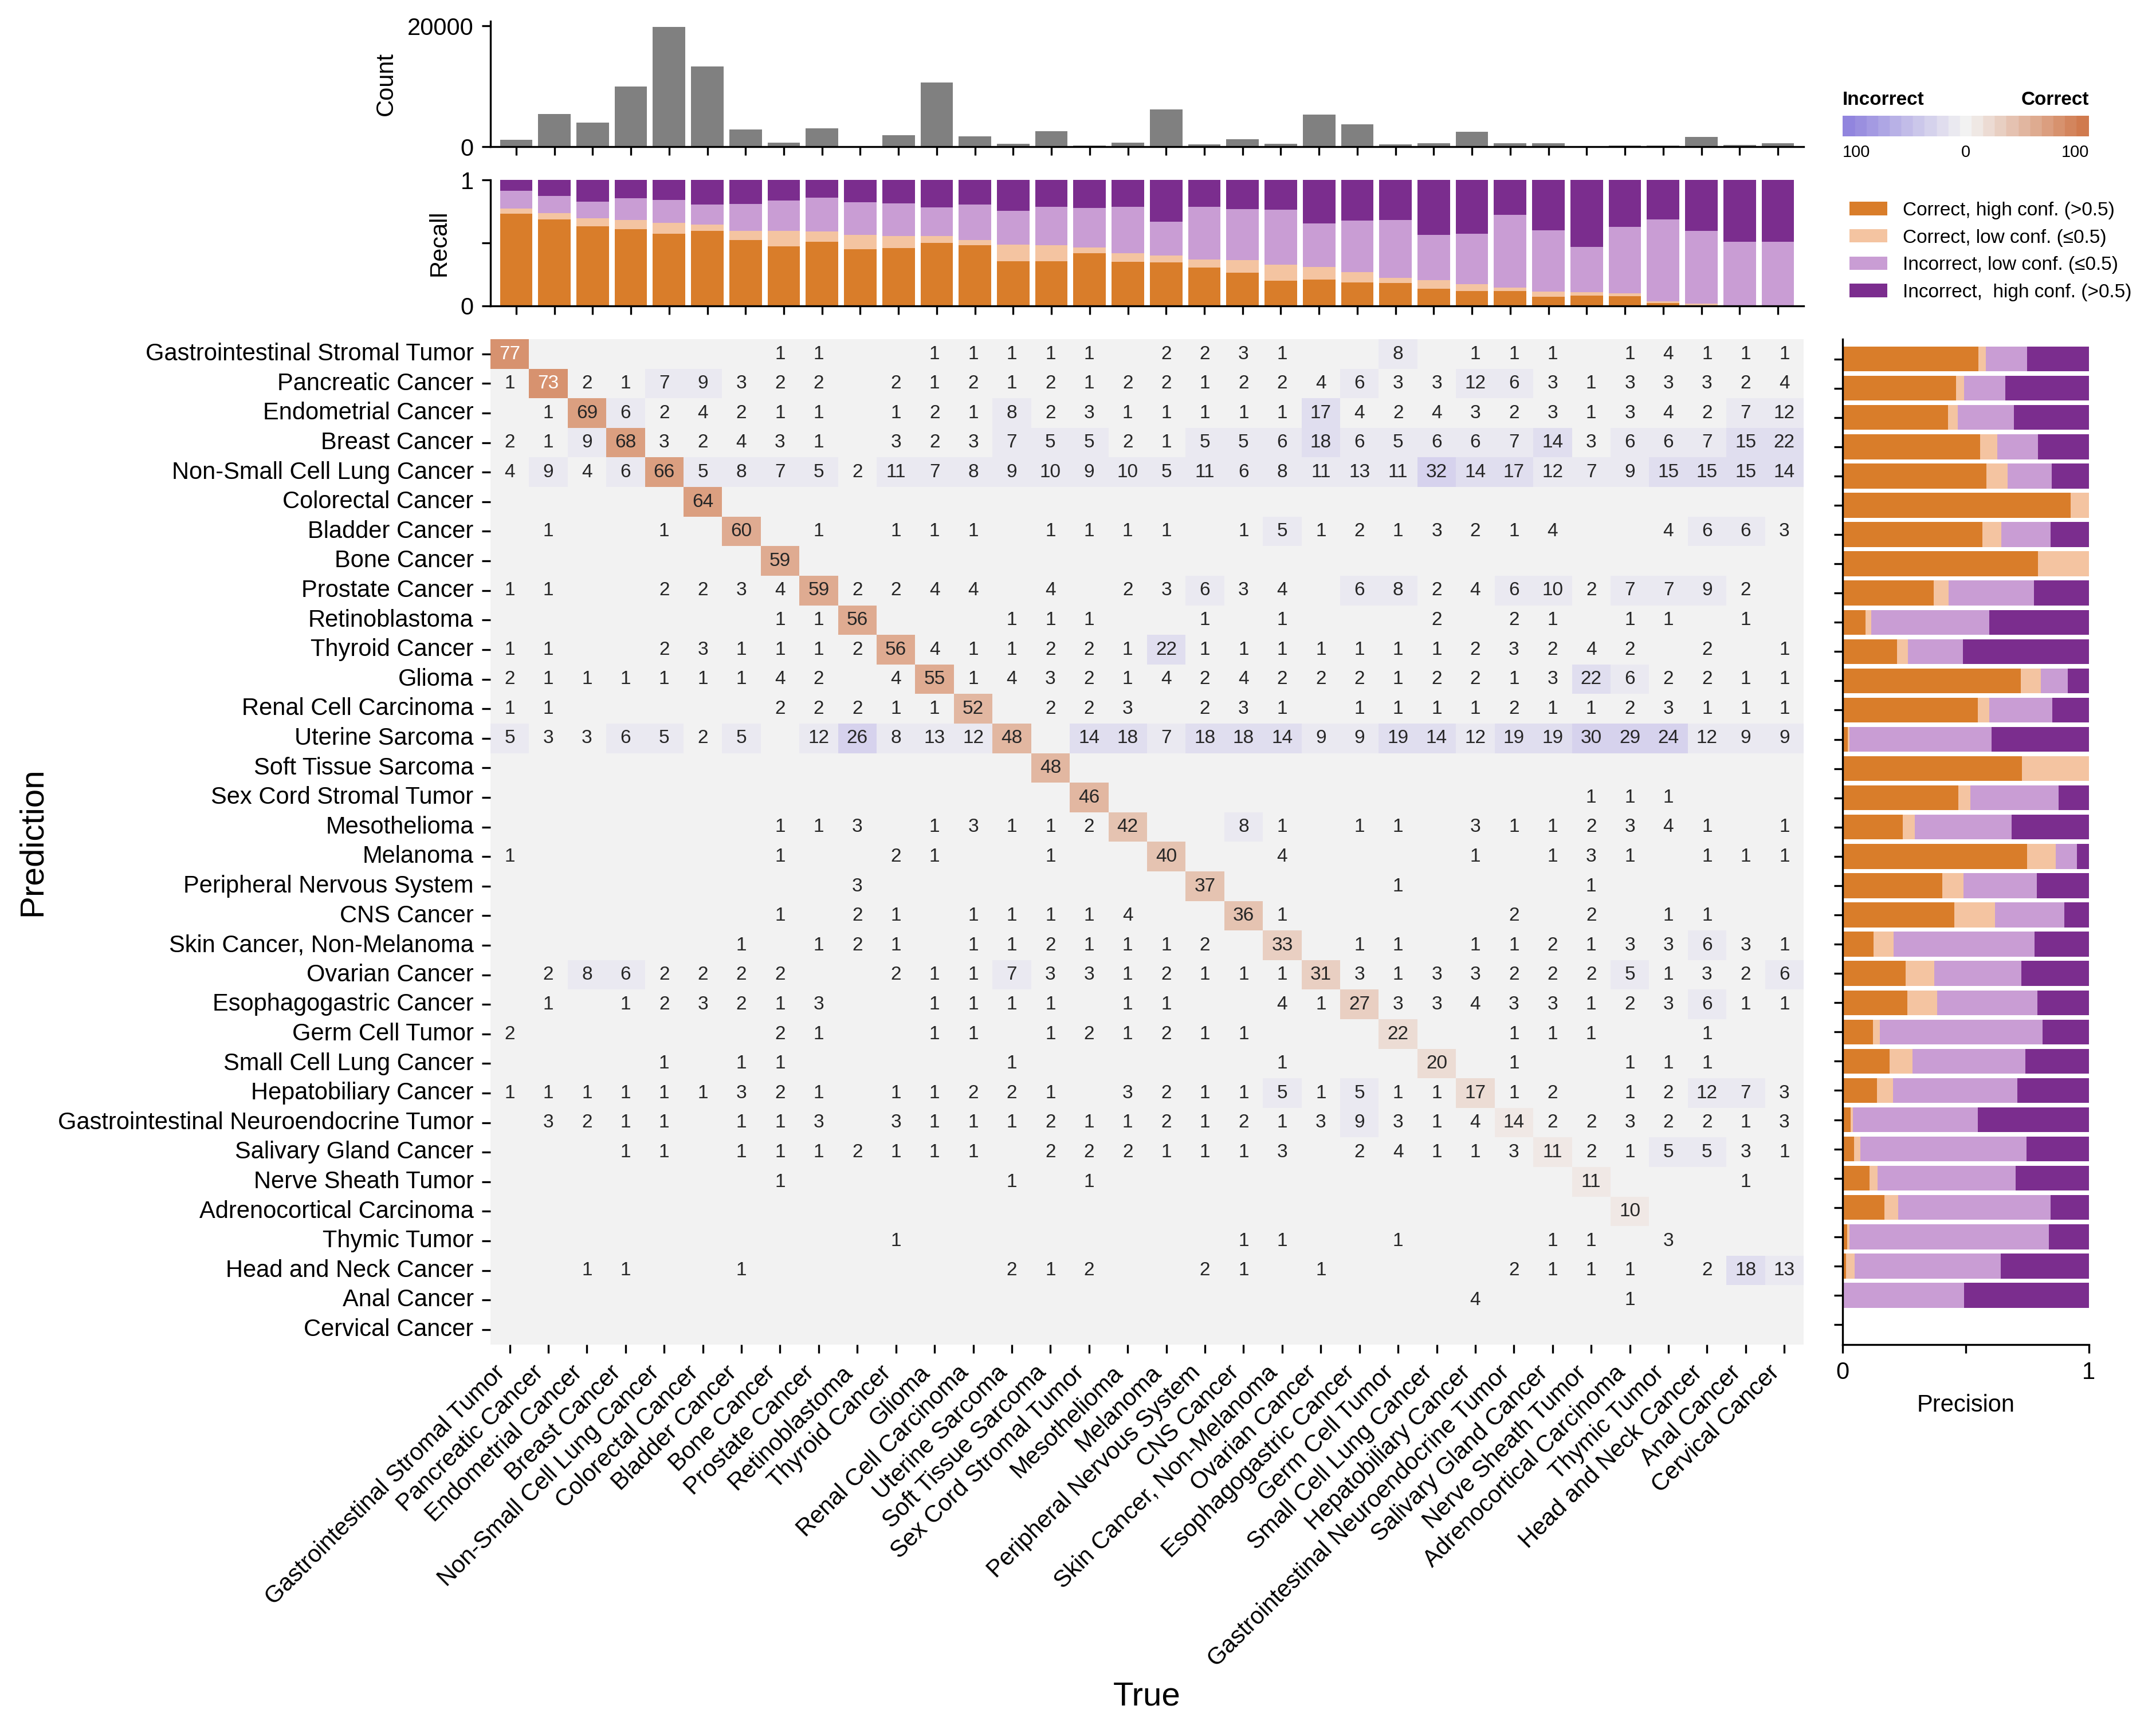

In [13]:
#items you need
# tl_fin = pd.read_csv('/home/darmofam/gdd_ens/orig_train_N.csv', index_col = 0)
tl_fin = val_cancertypes_gdd.groupby("ground_truth").size().to_frame('count')
# heatmap_only(tl_fin, stats_fin,tl_fin, cutoff = 0, normalize = 'pred', cbar = False, other = True, unknown = True)
# heatmap_maker(tl_fin, val_cancertypes_gdd, tl_fin, cutoff = 0, normalize = "pred", cbar = False, other = False, unknown = False)
heatmap_maker(tl_fin, val_cancertypes_gdd, tl_fin, cutoff = 0.5, normalize = "true", cbar = False, other = False, unknown = False, filename="gdd_cm.pdf")

In [7]:
df_clean = val_cancertypes_gdd.dropna(subset=['ground_truth', 'prediction1'])

# Convert both columns to string type
df_clean['ground_truth'] = df_clean['ground_truth'].astype(str)
df_clean['prediction1'] = df_clean['prediction1'].astype(str)
indetermined = (set(df_clean['prediction1']) - set(df_clean['ground_truth']))
print(indetermined)
df_clean.loc[df_clean['prediction1'].isin(indetermined), 'prediction1'] = 'indetermined'

# Ensure consistent labels
labels = sorted(set(df_clean['ground_truth']) | set(df_clean['prediction1']))

# Compute metrics
accuracy = accuracy_score(df_clean['ground_truth'], df_clean['prediction1'])
precision = precision_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
recall = recall_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
f1 = f1_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
# Top-2: correct if either prediction1 or prediction2 is correct
df_clean['top2_correct'] = (
    (df_clean['ground_truth'] == df_clean['prediction1']) |
    (df_clean['ground_truth'] == df_clean['prediction2'])
)
top2_accuracy = df_clean['top2_correct'].mean()

# Print results
print(f"-----------GDD (N = {len(df_clean)})-----------")
print(f"Accuracy: {accuracy:.4f}")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 (weighted): {f1:.4f}")

# Filter out 'indetermined' prediction1s
df_filtered = df_clean[df_clean['prediction1'] != 'indetermined']

# Compute metrics
accuracy = accuracy_score(df_filtered['ground_truth'], df_filtered['prediction1'])
precision = precision_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)
recall = recall_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)
f1 = f1_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)

# Top-2: correct if either prediction1 or prediction2 is correct
df_filtered['top2_correct'] = (
    (df_filtered['ground_truth'] == df_filtered['prediction1']) |
    (df_filtered['ground_truth'] == df_filtered['prediction2'])
)
top2_accuracy = df_clean['top2_correct'].mean()

# Print results
print("-----------without indetermined-----------")
print(f"There are {len(df_clean) - len(df_filtered)} samples out of {len(df_clean)} that are indetermined")
print(f"Accuracy: {accuracy:.4f}")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 (weighted): {f1:.4f}")

set()
-----------GDD (N = 102791)-----------
Accuracy: 0.5468
Top-2 Accuracy: 0.6585
Precision (weighted): 0.6361
Recall (weighted): 0.5468
F1 (weighted): 0.5702
-----------without indetermined-----------
There are 0 samples out of 102791 that are indetermined
Accuracy: 0.5468
Top-2 Accuracy: 0.6585
Precision (weighted): 0.6361
Recall (weighted): 0.5468
F1 (weighted): 0.5702


## O3-mini

/tmp/ipykernel_3461451/3453676485.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


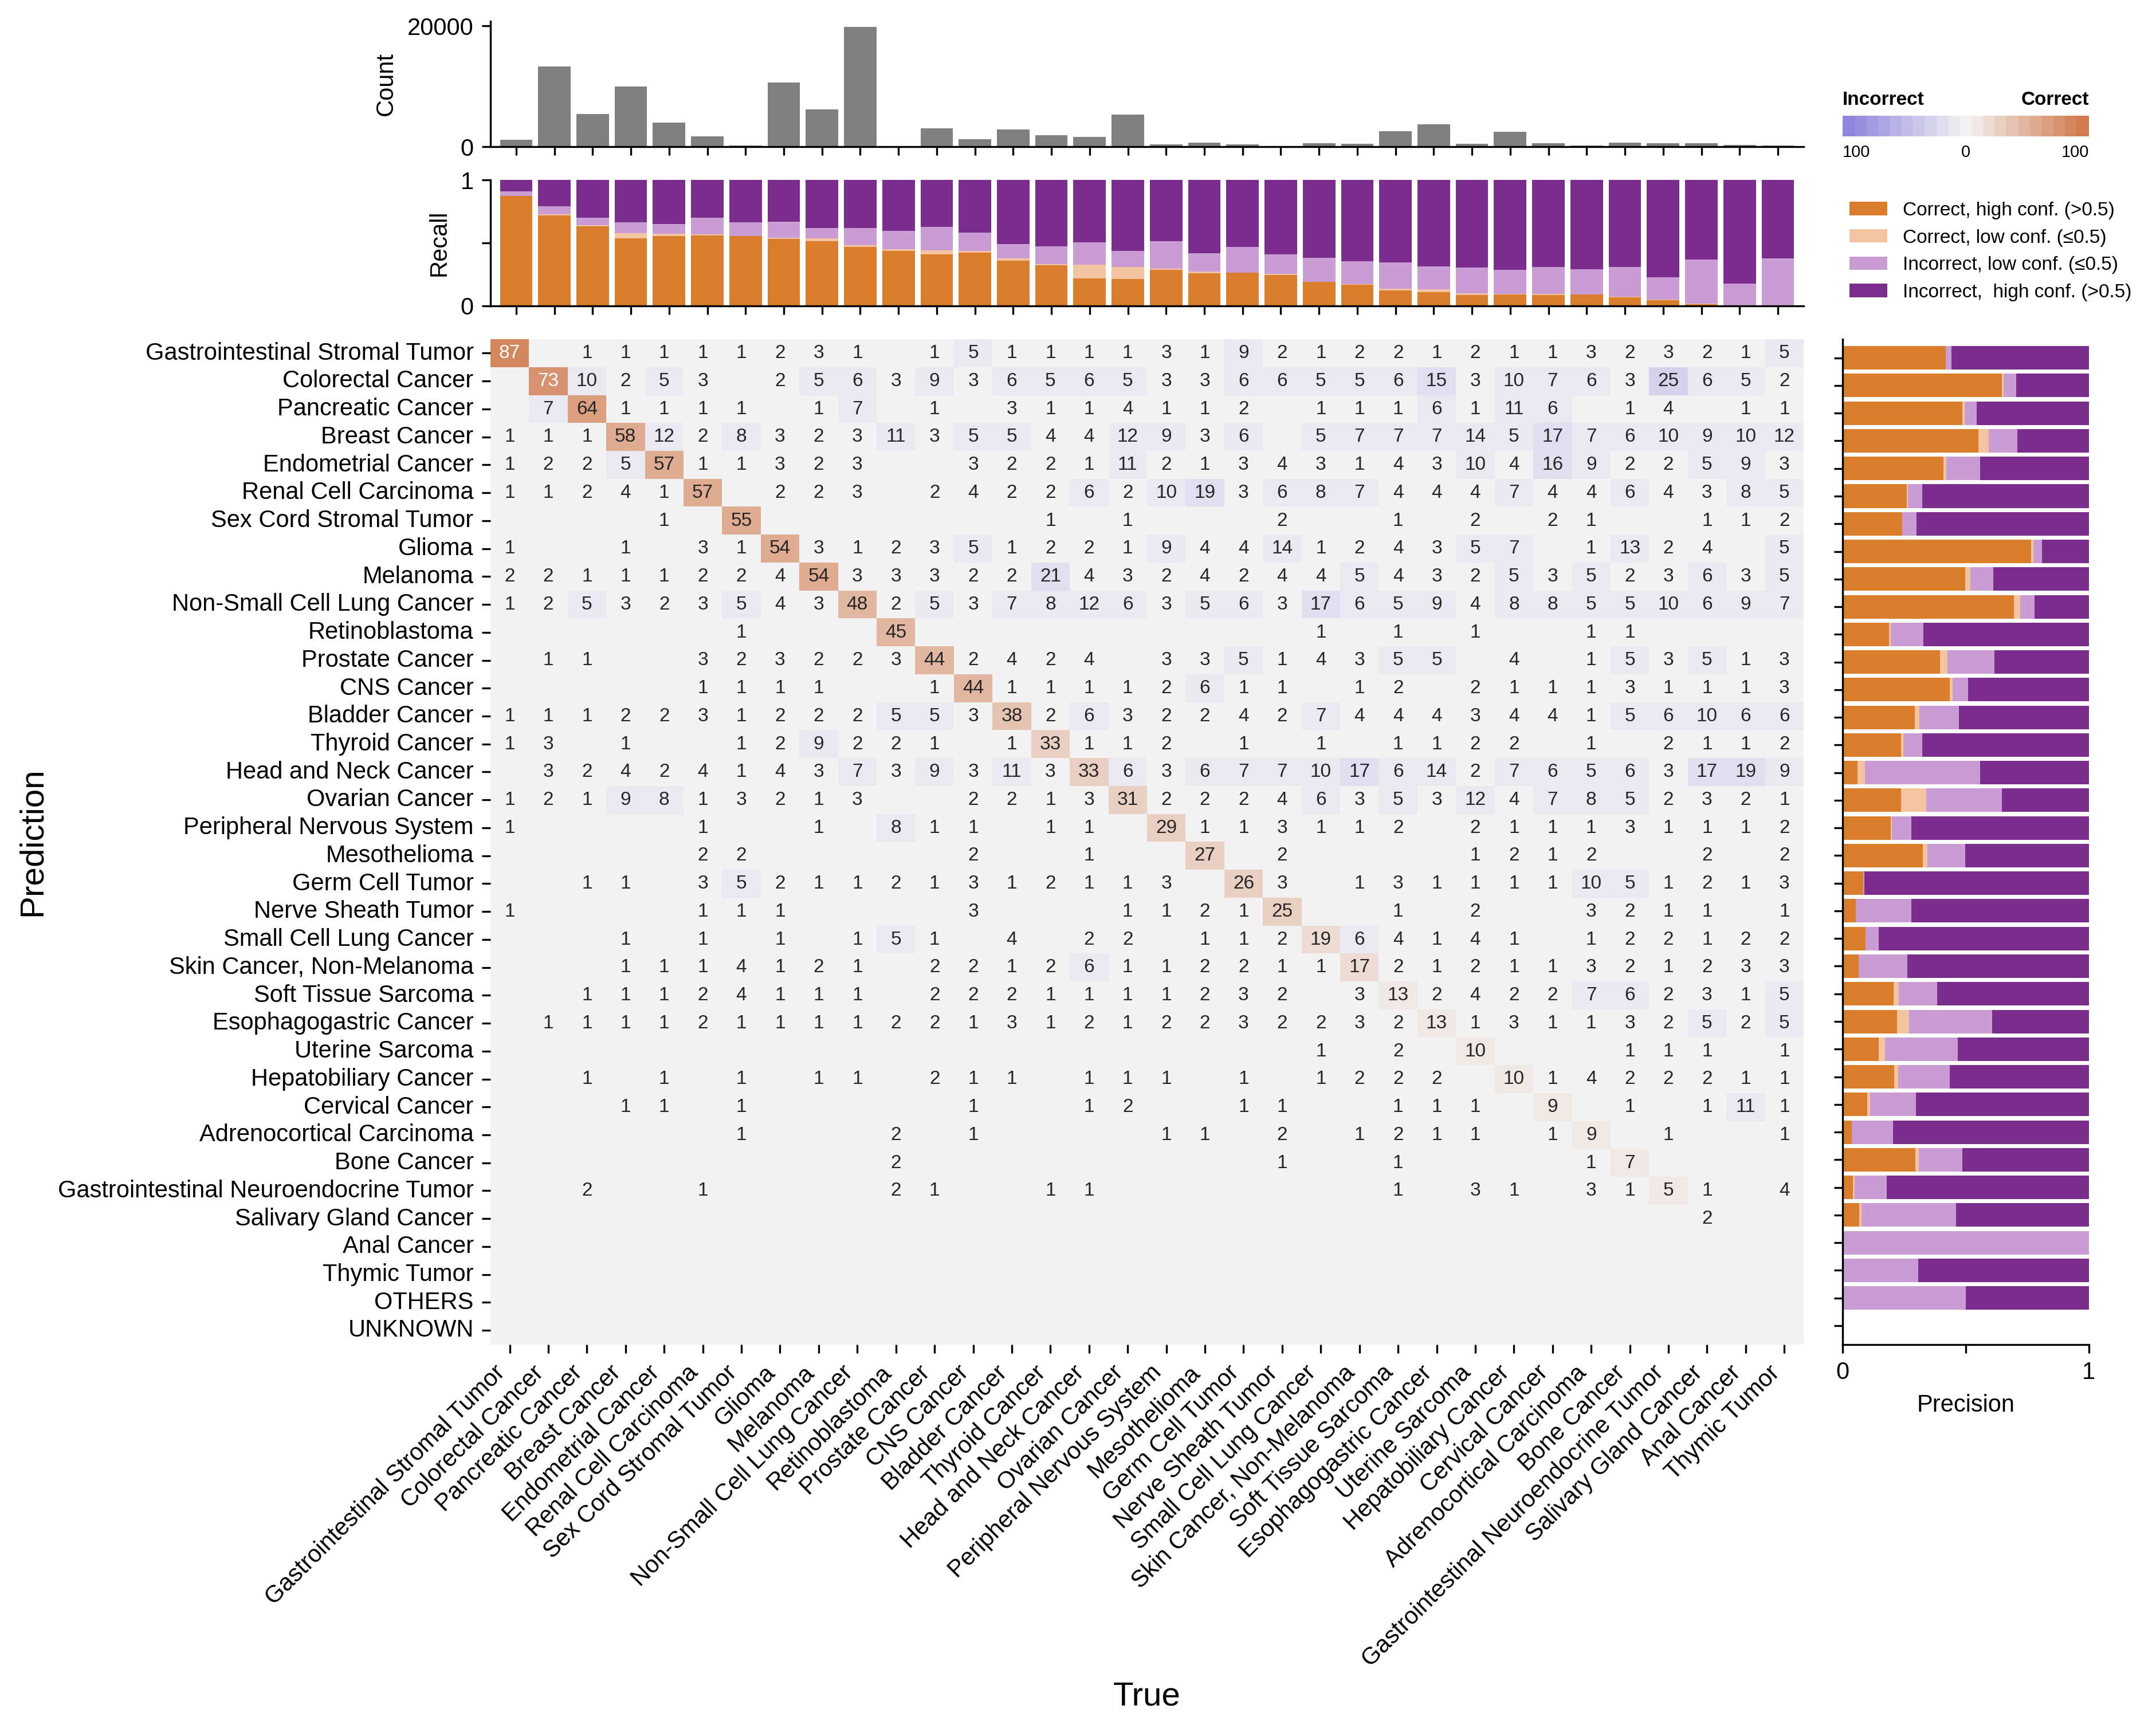

In [12]:
#items you need
# tl_fin = pd.read_csv('/home/darmofam/gdd_ens/orig_train_N.csv', index_col = 0)
tl_fin = val_cancertypes.groupby("ground_truth").size().to_frame('count')
# heatmap_only(tl_fin, stats_fin,tl_fin, cutoff = 0, normalize = 'pred', cbar = False, other = True, unknown = True)
# heatmap_maker(tl_fin, val_cancertypes, tl_fin, cutoff = 0, normalize = "pred", cbar = False, other = True, unknown = True)
heatmap_maker(tl_fin, val_cancertypes, tl_fin, cutoff = 0.5, normalize = "true", cbar = False, other = True, unknown = True, filename="gpt5_cm.pdf")

In [6]:
df_clean = val_cancertypes.dropna(subset=['ground_truth', 'prediction1'])

# Convert both columns to string type
df_clean['ground_truth'] = df_clean['ground_truth'].astype(str)
df_clean['prediction1'] = df_clean['prediction1'].astype(str)
indetermined = (set(df_clean['prediction1']) - set(df_clean['ground_truth']))
print(indetermined)
df_clean.loc[df_clean['prediction1'].isin(indetermined), 'prediction1'] = 'indetermined'

# Ensure consistent labels
labels = sorted(set(df_clean['ground_truth']) | set(df_clean['prediction1']))

# Compute metrics
accuracy = accuracy_score(df_clean['ground_truth'], df_clean['prediction1'])
precision = precision_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
recall = recall_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
f1 = f1_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
# Top-2: correct if either prediction1 or prediction2 is correct
df_clean['top2_correct'] = (
    (df_clean['ground_truth'] == df_clean['prediction1']) |
    (df_clean['ground_truth'] == df_clean['prediction2'])
)
top2_accuracy = df_clean['top2_correct'].mean()

# Print results
print(f"-----------O3-mini (N = {len(df_clean)})-----------")
print(f"Accuracy: {accuracy:.4f}")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 (weighted): {f1:.4f}")

# Filter out 'indetermined' prediction1s
df_filtered = df_clean[df_clean['prediction1'] != 'indetermined']

# Compute metrics
accuracy = accuracy_score(df_filtered['ground_truth'], df_filtered['prediction1'])
precision = precision_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)
recall = recall_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)
f1 = f1_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)

# Top-2: correct if either prediction1 or prediction2 is correct
df_filtered['top2_correct'] = (
    (df_filtered['ground_truth'] == df_filtered['prediction1']) |
    (df_filtered['ground_truth'] == df_filtered['prediction2'])
)
top2_accuracy = df_clean['top2_correct'].mean()

# Print results
print("-----------without indetermined-----------")
print(f"There are {len(df_clean) - len(df_filtered)} samples out of {len(df_clean)} that are indetermined")
print(f"Accuracy: {accuracy:.4f}")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 (weighted): {f1:.4f}")

{'OTHERS'}
-----------O3-mini (N = 85808)-----------
Accuracy: 0.4431
Top-2 Accuracy: 0.5650
Precision (weighted): 0.4543
Recall (weighted): 0.4431
F1 (weighted): 0.4151
-----------without indetermined-----------
There are 507 samples out of 85808 that are indetermined
Accuracy: 0.4457
Top-2 Accuracy: 0.5650
Precision (weighted): 0.4549
Recall (weighted): 0.4457
F1 (weighted): 0.4167


/tmp/ipykernel_3113322/390206412.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['top2_correct'] = (


## MedGemma

/tmp/ipykernel_577953/2484015207.py:285: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


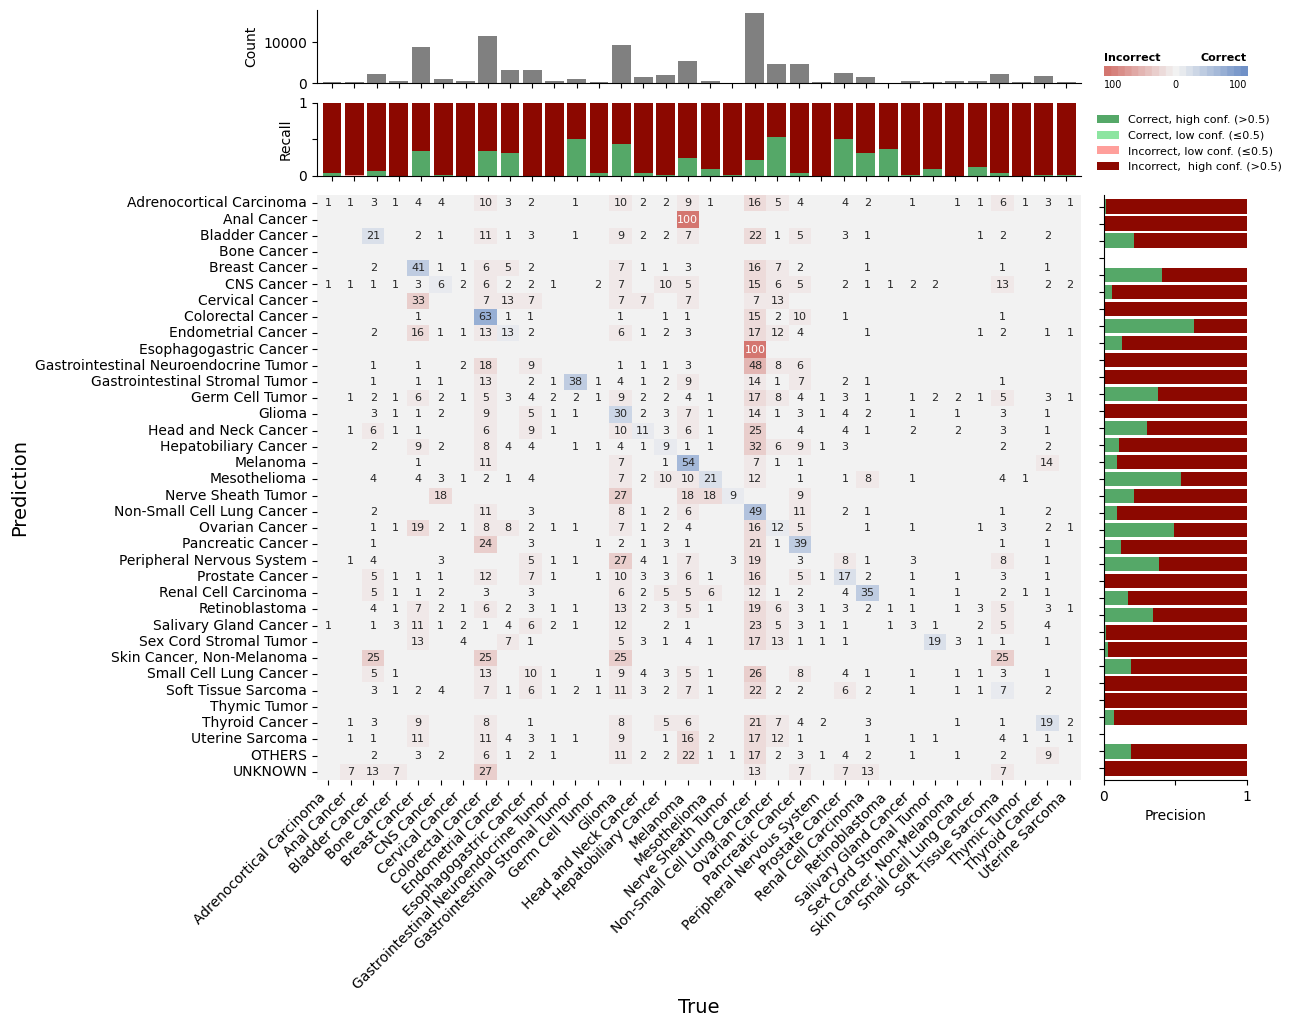

In [8]:
#items you need
# tl_fin = pd.read_csv('/home/darmofam/gdd_ens/orig_train_N.csv', index_col = 0)
tl_fin = val_cancertypes_gemma.groupby("ground_truth").size().to_frame('count')
# heatmap_maker(tl_fin, val_cancertypes_gemma, tl_fin, cutoff = 0, normalize = "pred", cbar = False, other = True, unknown = True)
heatmap_maker(tl_fin, val_cancertypes_gemma, tl_fin, cutoff = 0.5, normalize = "pred", cbar = False, other = True, unknown = True, filename="qwen3_cm.pdf")

In [13]:
df_clean = val_cancertypes_gemma.dropna(subset=['ground_truth', 'prediction1'])

# Convert both columns to string type
df_clean['ground_truth'] = df_clean['ground_truth'].astype(str)
df_clean['prediction1'] = df_clean['prediction1'].astype(str)
indetermined = (set(df_clean['prediction1']) - set(df_clean['ground_truth']))
print(indetermined)
df_clean.loc[df_clean['prediction1'].isin(indetermined), 'prediction1'] = 'indetermined'

# Ensure consistent labels
labels = sorted(set(df_clean['ground_truth']) | set(df_clean['prediction1']))

# Compute metrics
accuracy = accuracy_score(df_clean['ground_truth'], df_clean['prediction1'])
precision = precision_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
recall = recall_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
f1 = f1_score(df_clean['ground_truth'], df_clean['prediction1'], average='weighted', zero_division=0)
# Top-2: correct if either prediction1 or prediction2 is correct
df_clean['top2_correct'] = (
    (df_clean['ground_truth'] == df_clean['prediction1']) |
    (df_clean['ground_truth'] == df_clean['prediction2'])
)
top2_accuracy = df_clean['top2_correct'].mean()

# Print results
print(f"-----------MedGemma (N = {len(df_clean)})-----------")
print(f"Accuracy: {accuracy:.4f}")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 (weighted): {f1:.4f}")

# Filter out 'indetermined' prediction1s
df_filtered = df_clean[df_clean['prediction1'] != 'indetermined']

# Compute metrics
accuracy = accuracy_score(df_filtered['ground_truth'], df_filtered['prediction1'])
precision = precision_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)
recall = recall_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)
f1 = f1_score(df_filtered['ground_truth'], df_filtered['prediction1'], average='weighted', zero_division=0)
# Top-2: correct if either prediction1 or prediction2 is correct
df_filtered['top2_correct'] = (
    (df_filtered['ground_truth'] == df_filtered['prediction1']) |
    (df_filtered['ground_truth'] == df_filtered['prediction2'])
)
top2_accuracy = df_clean['top2_correct'].mean()

# Print results
print("-----------without indetermined-----------")
print(f"There are {len(df_clean) - len(df_filtered)} samples out of {len(df_clean)} that are indetermined")
print(f"Accuracy: {accuracy:.4f}")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 (weighted): {f1:.4f}")

{'OTHERS', 'UNKNOWN'}
-----------MedGemma (N = 96669)-----------
Accuracy: 0.2073
Top-2 Accuracy: 0.2791
Precision (weighted): 0.3234
Recall (weighted): 0.2073
F1 (weighted): 0.1924
-----------without indetermined-----------
There are 1056 samples out of 96669 that are indetermined
Accuracy: 0.2096
Top-2 Accuracy: 0.2791
Precision (weighted): 0.3230
Recall (weighted): 0.2096
F1 (weighted): 0.1939


/tmp/ipykernel_2425624/4227912739.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['top2_correct'] = (
